# Hypertension Treatment Outcomes — Zion Tech Hub Data Challenge

## Problem Statement

**Problem 1:** Identify which patient and treatment factors are associated with blood pressure being controlled within 3 months.

**Problem 2:** Build a predictive model that can flag which patients are likely to achieve BP control, so the clinic can prioritise and tailor treatment early.

The overall BP control rate in this dataset is only 9.4%. These two questions work together — the analysis explains *why* success is rare, and the model tries to predict *who* will succeed.

## 1. Load Data and Inspect Structure

We load the dataset and check three things before touching anything:
- How many rows and columns we have
- Whether any data is missing
- How many patients did vs did not get their BP controlled

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('Hypertension_Cardiology_Center_Dataset.csv')

# Basic shape check
print("Rows and columns:", df.shape)

# Column names and data types
print("\nColumn types:")
print(df.dtypes)

# Missing values check
print("\nMissing values per column:")
print(df.isnull().sum())

# Target variable distribution
print("\nBP Control outcomes:")
print(df['BP_Controlled_After_3_Months'].value_counts())
print(df['BP_Controlled_After_3_Months'].value_counts(normalize=True).round(3) * 100)

Rows and columns: (350, 16)

Column types:
Patient_ID                      object
Age                              int64
Gender                          object
Diabetes_Mellitus               object
Chronic_Kidney_Disease          object
Dyslipidemia                    object
Obesity                         object
Baseline_Systolic_BP             int64
Baseline_Diastolic_BP            int64
Antihypertensive_Class          object
Medication_Adherence            object
Followup_Systolic_BP             int64
Followup_Diastolic_BP            int64
BP_Controlled_After_3_Months    object
Number_of_Visits                 int64
Registration_Date               object
dtype: object

Missing values per column:
Patient_ID                      0
Age                             0
Gender                          0
Diabetes_Mellitus               0
Chronic_Kidney_Disease          0
Dyslipidemia                    0
Obesity                         0
Baseline_Systolic_BP            0
Baseline_Diastolic_

**Results:**
- 350 patients, 16 columns, no missing values — clean and ready to use
- 317 patients (90.6%) did **not** get their BP controlled. Only 33 (9.4%) did.

This heavy imbalance matters. Any model trained on this will naturally lean toward predicting failure. We correct for this later using `class_weight='balanced'`.

## Categorical Variable Counts

We count how many patients fall into each category across the text columns. This tells us who these patients are before any analysis begins.

In [2]:
# Check unique values in all categorical columns
categorical_cols = ['Gender', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease',
                    'Dyslipidemia', 'Obesity', 'Antihypertensive_Class',
                    'Medication_Adherence', 'BP_Controlled_After_3_Months']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Female    178
Male      172
Name: count, dtype: int64

Diabetes_Mellitus:
Diabetes_Mellitus
Yes    182
No     168
Name: count, dtype: int64

Chronic_Kidney_Disease:
Chronic_Kidney_Disease
Yes    182
No     168
Name: count, dtype: int64

Dyslipidemia:
Dyslipidemia
No     187
Yes    163
Name: count, dtype: int64

Obesity:
Obesity
Yes    186
No     164
Name: count, dtype: int64

Antihypertensive_Class:
Antihypertensive_Class
ARB                        68
Beta Blocker               61
Thiazide Diuretic          61
Calcium Channel Blocker    58
Combination Therapy        57
ACE Inhibitor              45
Name: count, dtype: int64

Medication_Adherence:
Medication_Adherence
Moderate    132
Poor        113
Good        105
Name: count, dtype: int64

BP_Controlled_After_3_Months:
BP_Controlled_After_3_Months
No     317
Yes     33
Name: count, dtype: int64


**Results:**
- Gender is roughly equal (178F / 172M)
- Over half the patients have diabetes and chronic kidney disease
- Over half are obese
- Only 105 out of 350 patients (30%) have good medication adherence

This is a high-risk patient population. The majority have multiple conditions that make blood pressure harder to control. This context sits behind every finding in this notebook.

## Summary Statistics — Numeric Columns

We look at the averages and ranges for age, BP readings, and number of visits. This tells us how severe these cases are at baseline.

In [3]:
# Summary statistics for numeric columns
numeric_cols = ['Age', 'Baseline_Systolic_BP', 'Baseline_Diastolic_BP',
                'Followup_Systolic_BP', 'Followup_Diastolic_BP', 'Number_of_Visits']

df[numeric_cols].describe().round(1)

,Age,Baseline_Systolic_BP,Baseline_Diastolic_BP,Followup_Systolic_BP,Followup_Diastolic_BP,Number_of_Visits
count,350.0,350.0,350.0,350.0,350.0,350.0
mean,57.4,166.0,105.3,151.5,97.0,3.4
std,16.0,14.5,8.7,16.5,9.9,1.7
min,30.0,140.0,90.0,110.0,72.0,1.0
25%,43.2,155.0,98.0,141.0,89.0,2.0
50%,57.5,167.0,106.0,152.5,97.0,3.0
75%,71.8,179.0,112.0,163.0,104.0,5.0
max,85.0,190.0,120.0,186.0,120.0,6.0


**Results:**
- Average age: 57 years
- Average baseline systolic BP: **166 mmHg** — well above the controlled threshold of 140 mmHg
- Average baseline diastolic BP: 105 mmHg — also elevated

These are not mild cases. Patients are starting far above the target, which makes reaching it within 3 months genuinely difficult.

## BP Control Rate by Drug Class

We calculate the percentage of patients whose BP was controlled for each drug type. This answers: which medications are associated with better outcomes in this dataset?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22776\601660894.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=drug_control, x='Drug_Class', y='Control_Rate_%', palette='Blues_d')


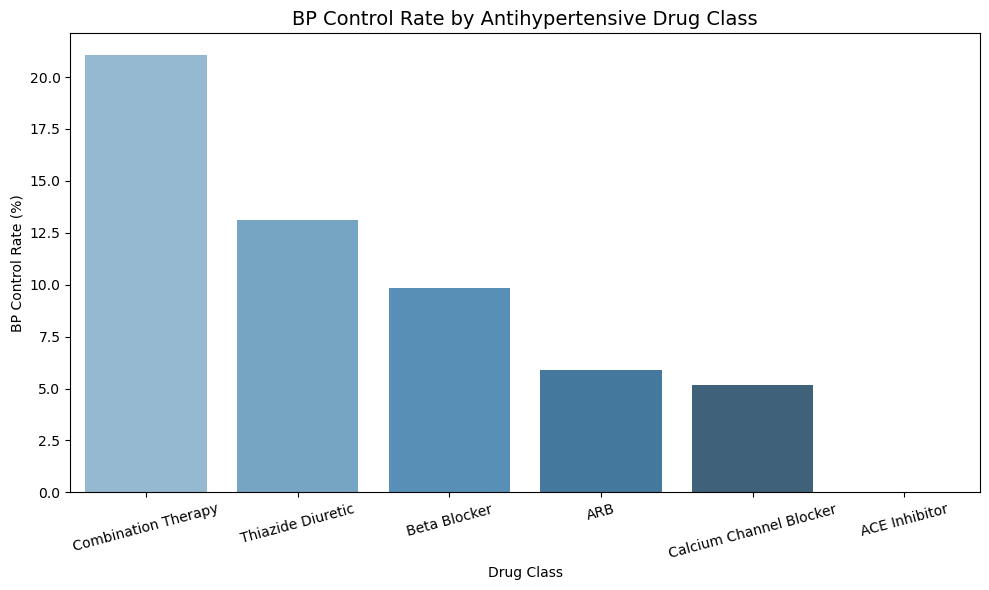

             Drug_Class  Control_Rate_%
    Combination Therapy       21.052632
      Thiazide Diuretic       13.114754
           Beta Blocker        9.836066
                    ARB        5.882353
Calcium Channel Blocker        5.172414
          ACE Inhibitor        0.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate BP control rate by drug class
drug_control = df.groupby('Antihypertensive_Class')['BP_Controlled_After_3_Months']\
                 .apply(lambda x: (x == 'Yes').mean() * 100)\
                 .reset_index()
drug_control.columns = ['Drug_Class', 'Control_Rate_%']
drug_control = drug_control.sort_values('Control_Rate_%', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=drug_control, x='Drug_Class', y='Control_Rate_%', palette='Blues_d')
plt.title('BP Control Rate by Antihypertensive Drug Class', fontsize=14)
plt.xlabel('Drug Class')
plt.ylabel('BP Control Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart1_drug_control_rate.png', dpi=150)
plt.show()

print(drug_control.to_string(index=False))

**Results:**
Combination therapy performed more than twice as well as any single drug. ACE Inhibitors had a 0% control rate across 45 patients.

> ⚠️ The 0% ACE Inhibitor result likely reflects that sicker patients were assigned this drug — not that the drug doesn't work. ACE Inhibitors are clinically recommended for patients with diabetes and CKD. Do not draw prescribing conclusions from this alone.

## BP Control Rate by Medication Adherence

We check how strongly medication adherence, whether patients actually take their medication, relates to outcomes. This is one of the few factors the clinic can directly intervene on.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22776\2373346647.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=adherence_control, x='Adherence_Level', y='Control_Rate_%',


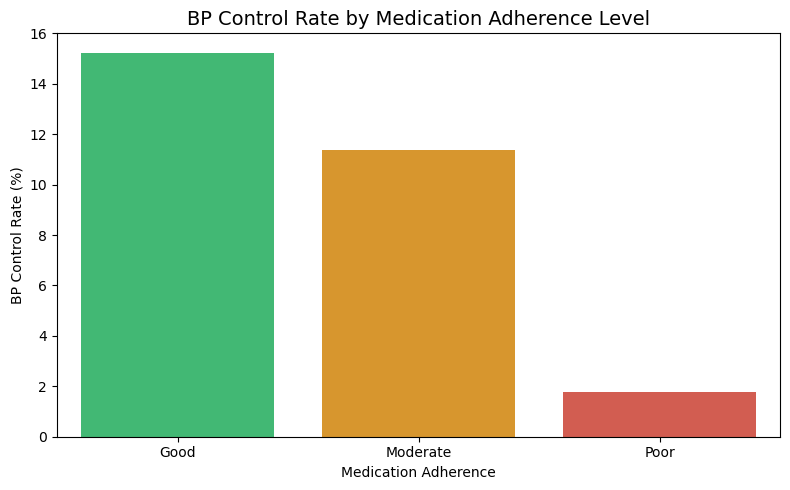

Adherence_Level  Control_Rate_%
           Good       15.238095
       Moderate       11.363636
           Poor        1.769912


In [7]:
# Calculate BP control rate by medication adherence
adherence_control = df.groupby('Medication_Adherence')['BP_Controlled_After_3_Months']\
                      .apply(lambda x: (x == 'Yes').mean() * 100)\
                      .reset_index()
adherence_control.columns = ['Adherence_Level', 'Control_Rate_%']

# Define logical order
order = ['Good', 'Moderate', 'Poor']
adherence_control['Adherence_Level'] = pd.Categorical(
    adherence_control['Adherence_Level'], categories=order, ordered=True)
adherence_control = adherence_control.sort_values('Adherence_Level')

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=adherence_control, x='Adherence_Level', y='Control_Rate_%',
            palette=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('BP Control Rate by Medication Adherence Level', fontsize=14)
plt.xlabel('Medication Adherence')
plt.ylabel('BP Control Rate (%)')
plt.tight_layout()
plt.savefig('chart2_adherence_control_rate.png', dpi=150)
plt.show()

print(adherence_control.to_string(index=False))

**Results:**

Patients with good adherence were roughly **8× more likely** to succeed than those with poor adherence. This is the most actionable finding in the exploratory analysis, adherence support (reminders, follow-up calls, patient education) is something the clinic can directly change.

## 6. BP Control Rate by Comorbidity

For each of the four conditions: diabetes, chronic kidney disease, dyslipidemia, and obesity, we compare control rates between patients who have it and those who don't. This tells us which conditions make BP hardest to manage.

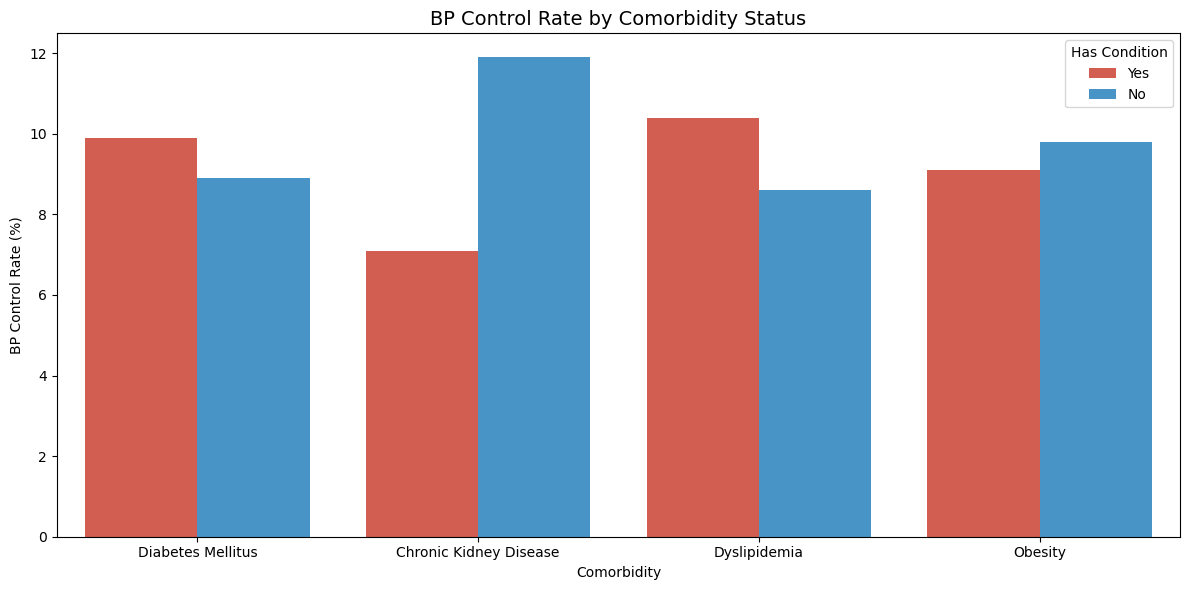

           Comorbidity Status  Control_Rate_%
     Diabetes Mellitus    Yes             9.9
     Diabetes Mellitus     No             8.9
Chronic Kidney Disease    Yes             7.1
Chronic Kidney Disease     No            11.9
          Dyslipidemia    Yes            10.4
          Dyslipidemia     No             8.6
               Obesity    Yes             9.1
               Obesity     No             9.8


In [9]:
# Calculate BP control rate for each comorbidity
comorbidities = ['Diabetes_Mellitus', 'Chronic_Kidney_Disease', 
                 'Dyslipidemia', 'Obesity']

results = []
for col in comorbidities:
    for value in ['Yes', 'No']:
        rate = (df[df[col] == value]['BP_Controlled_After_3_Months'] == 'Yes').mean() * 100
        results.append({'Comorbidity': col.replace('_', ' '), 
                       'Status': value, 
                       'Control_Rate_%': round(rate, 1)})

comorbidity_df = pd.DataFrame(results)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=comorbidity_df, x='Comorbidity', y='Control_Rate_%', 
            hue='Status', palette=['#e74c3c', '#3498db'])
plt.title('BP Control Rate by Comorbidity Status', fontsize=14)
plt.xlabel('Comorbidity')
plt.ylabel('BP Control Rate (%)')
plt.legend(title='Has Condition')
plt.tight_layout()
plt.savefig('chart3_comorbidity_control_rate.png', dpi=150)
plt.show()

print(comorbidity_df.to_string(index=False))

**Results:**

Most conditions have a small effect. Chronic kidney disease stands out, patients with CKD had a noticeably lower control rate (7.1% vs 11.9%). This is clinically expected: CKD disrupts how the kidneys regulate blood pressure, making it harder to control.

## Baseline BP vs Follow-up BP

We plot each patient's starting systolic BP against their follow-up BP, coloured by outcome. This shows not just who succeeded, but how much BP actually changed in both groups, which matters for understanding what "failure" really means here.

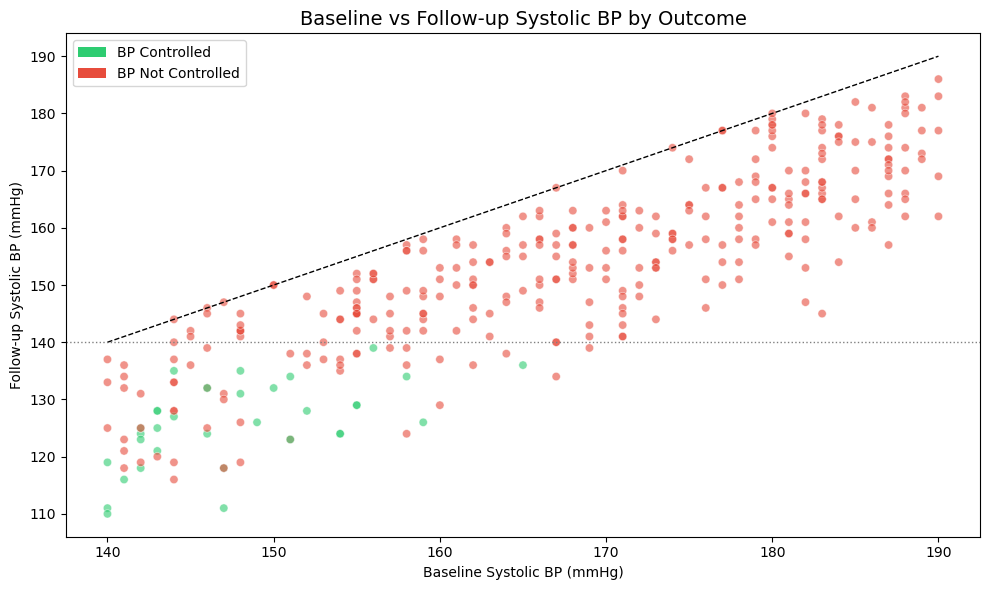

                              count  mean  std  min   25%   50%   75%   max
BP_Controlled_After_3_Months                                               
No                            317.0  13.7  8.0  0.0   8.0  13.0  19.0  38.0
Yes                            33.0  22.3  6.5  9.0  17.0  22.0  28.0  36.0


In [11]:
# Map outcome to color
color_map = {'Yes': '#2ecc71', 'No': '#e74c3c'}
colors = df['BP_Controlled_After_3_Months'].map(color_map)

plt.figure(figsize=(10, 6))
plt.scatter(df['Baseline_Systolic_BP'], df['Followup_Systolic_BP'],
            c=colors, alpha=0.6, edgecolors='white', linewidth=0.5)

# Reference line — if dot sits on this line, BP did not change
plt.plot([140, 190], [140, 190], 'k--', linewidth=1, label='No change line')

# Mark the control threshold
plt.axhline(y=140, color='gray', linestyle=':', linewidth=1, label='Control threshold (140)')

plt.title('Baseline vs Follow-up Systolic BP by Outcome', fontsize=14)
plt.xlabel('Baseline Systolic BP (mmHg)')
plt.ylabel('Follow-up Systolic BP (mmHg)')

# Manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='BP Controlled'),
                   Patch(facecolor='#e74c3c', label='BP Not Controlled')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('chart4_bp_scatter.png', dpi=150)
plt.show()

# Print average BP drop by outcome
df['BP_Drop'] = df['Baseline_Systolic_BP'] - df['Followup_Systolic_BP']
print(df.groupby('BP_Controlled_After_3_Months')['BP_Drop'].describe().round(1))

**Results:**

Both groups improved, but only the controlled group dropped enough to cross below 140 mmHg. Many "failed" patients came close. Failure here often means *not enough improvement*, not *no improvement at all*.

## BP Control Rate by Age Group

We split patients into age bands and check control rates per group. This tells us whether age is a useful predictor of treatment success.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22776\3186347199.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_control, x='Age_Group', y='Control_Rate_%', palette='coolwarm')


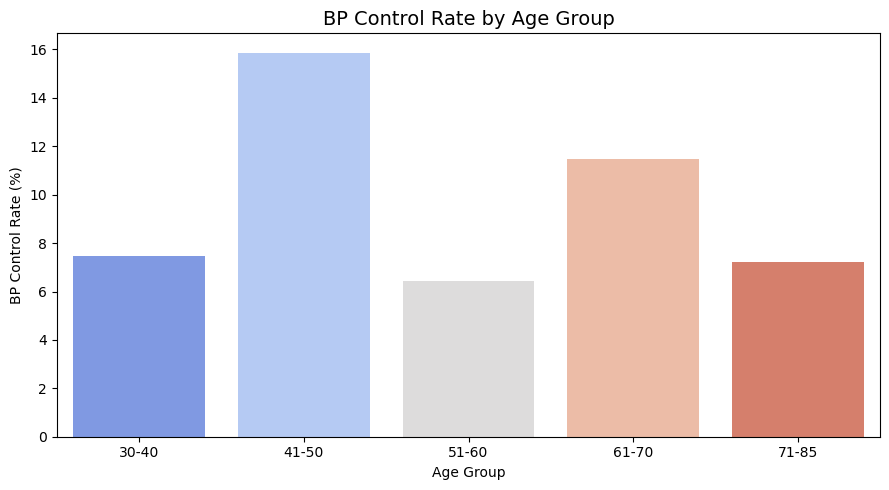

Age_Group  Control_Rate_%
    30-40        7.462687
    41-50       15.873016
    51-60        6.451613
    61-70       11.475410
    71-85        7.216495


In [13]:
# Create age groups
bins = [29, 40, 50, 60, 70, 86]
labels = ['30-40', '41-50', '51-60', '61-70', '71-85']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Control rate by age group
age_control = df.groupby('Age_Group', observed=True)['BP_Controlled_After_3_Months']\
                .apply(lambda x: (x == 'Yes').mean() * 100)\
                .reset_index()
age_control.columns = ['Age_Group', 'Control_Rate_%']

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(data=age_control, x='Age_Group', y='Control_Rate_%', palette='coolwarm')
plt.title('BP Control Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('BP Control Rate (%)')
plt.tight_layout()
plt.savefig('chart5_age_control_rate.png', dpi=150)
plt.show()

print(age_control.to_string(index=False))

**Results:**

No clear trend with age, rates go up and down across groups. Age on its own is not a reliable predictor. Each group is also small, so do not over-interpret these differences.

## Correlation Heatmap

A correlation is a number between -1 and +1 that measures how closely two things move together. Here we check which numeric variables are most related to BP being controlled. This helps us decide which features are worth including in the model.

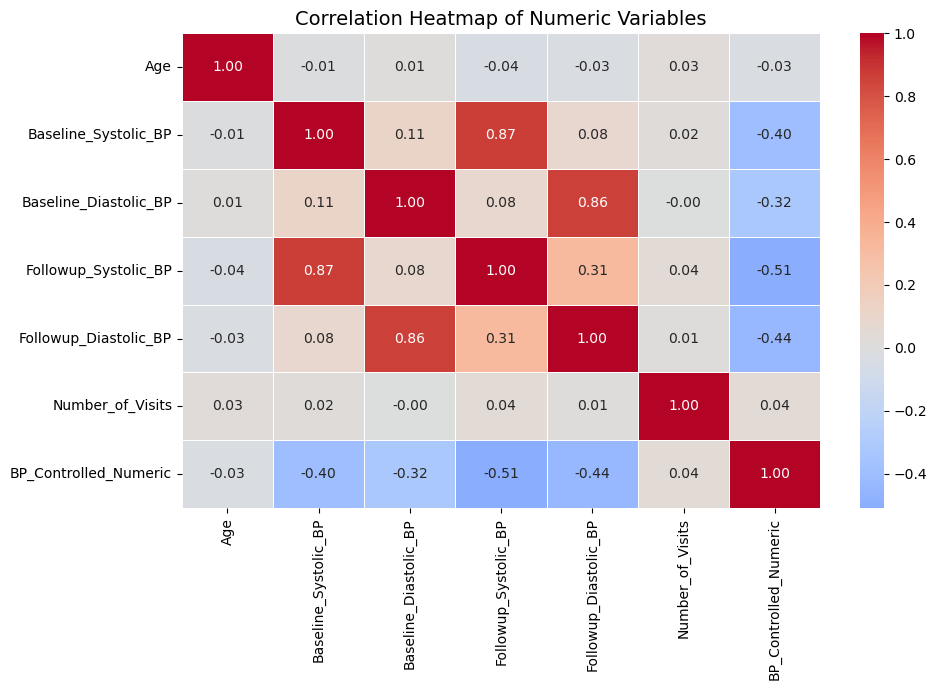

BP_Controlled_Numeric    1.00
Number_of_Visits         0.04
Age                     -0.03
Baseline_Diastolic_BP   -0.32
Baseline_Systolic_BP    -0.40
Followup_Diastolic_BP   -0.44
Followup_Systolic_BP    -0.51
Name: BP_Controlled_Numeric, dtype: float64


In [15]:
# Encode target variable temporarily for correlation
df['BP_Controlled_Numeric'] = (df['BP_Controlled_After_3_Months'] == 'Yes').astype(int)

# Select numeric columns including encoded target
corr_cols = ['Age', 'Baseline_Systolic_BP', 'Baseline_Diastolic_BP',
             'Followup_Systolic_BP', 'Followup_Diastolic_BP',
             'Number_of_Visits', 'BP_Controlled_Numeric']

corr_matrix = df[corr_cols].corr().round(2)

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png', dpi=150)
plt.show()

print(corr_matrix['BP_Controlled_Numeric'].sort_values(ascending=False))

**Results (correlation with BP control):**

Higher starting BP strongly predicts failure. Age and number of visits are barely related to outcome.

## Preparing Features for Modelling

We select only the information a doctor would have *at the time of prescribing*, no follow-up measurements. We then convert text categories into numbers so the model can use them.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Define features the doctor knows at prescription time only
features = ['Age', 'Gender', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease',
            'Dyslipidemia', 'Obesity', 'Baseline_Systolic_BP',
            'Baseline_Diastolic_BP', 'Antihypertensive_Class',
            'Medication_Adherence', 'Number_of_Visits']

# Create modeling dataframe
model_df = df[features + ['BP_Controlled_After_3_Months']].copy()

# Encode categorical variables
le = LabelEncoder()
categorical_features = ['Gender', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease',
                        'Dyslipidemia', 'Obesity', 'Antihypertensive_Class',]

# Fix Medication Adherence encoding to reflect clinical risk order
adherence_map = {'Good': 0, 'Moderate': 1, 'Poor': 2}
model_df['Medication_Adherence'] = df['Medication_Adherence'].map(adherence_map)

for col in categorical_features:
    model_df[col] = le.fit_transform(model_df[col])

# Encode target variable
model_df['Target'] = (model_df['BP_Controlled_After_3_Months'] == 'Yes').astype(int)

# Confirm
print("Shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df['Target'].value_counts())
print("\nFirst 3 rows of prepared data:")
print(model_df[features].head(3))

Shape: (350, 13)

Target distribution:
Target
0    317
1     33
Name: count, dtype: int64

First 3 rows of prepared data:
   Age  Gender  Diabetes_Mellitus  Chronic_Kidney_Disease  Dyslipidemia  \
0   70       1                  1                       0             1   
1   35       1                  1                       1             1   
2   39       1                  0                       1             1   

   Obesity  Baseline_Systolic_BP  Baseline_Diastolic_BP  \
0        1                   148                    113   
1        0                   154                    104   
2        0                   146                    101   

   Antihypertensive_Class  Medication_Adherence  Number_of_Visits  
0                       0                     2                 1  
1                       2                     1                 3  
2                       3                     2                 5  


**What was done:**
- 11 features selected: age, gender, comorbidities, baseline BP, drug class, adherence, number of visits
- Medication adherence encoded as Good=0, Moderate=1, Poor=2 — preserving the clinical order ✅
- Other categories encoded with `LabelEncoder`

## Train-Test Split

We divide the data: 80% (280 patients) to train the model, 20% (70 patients) to test it on patients it has never seen. Stratified means both halves keep the same 90/10 split of outcomes.

In [20]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = model_df[features]
y = model_df['Target']

# Split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm shapes
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())

Training set size: (280, 11)
Test set size: (70, 11)

Training target distribution:
Target
0    254
1     26
Name: count, dtype: int64

Test target distribution:
Target
0    63
1     7
Name: count, dtype: int64


**Results:**
- Training: 254 not controlled, 26 controlled
- Test: 63 not controlled, 7 controlled

## Model Training and Evaluation

We train two models: **Logistic Regression** (simpler, more interpretable) and **Random Forest** (more complex). Both use `class_weight='balanced'` so the model does not ignore the small group of controlled patients.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print(confusion_matrix(y_test, lr_preds))
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['Not Controlled', 'Controlled']))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]).round(3))

print("\n" + "=" * 50)
print(confusion_matrix(y_test, rf_preds))
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_preds, target_names=['Not Controlled', 'Controlled']))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]).round(3))

LOGISTIC REGRESSION RESULTS
[[58  5]
 [ 1  6]]
                precision    recall  f1-score   support

Not Controlled       0.98      0.92      0.95        63
    Controlled       0.55      0.86      0.67         7

      accuracy                           0.91        70
     macro avg       0.76      0.89      0.81        70
  weighted avg       0.94      0.91      0.92        70

ROC-AUC Score: 0.982

[[63  0]
 [ 4  3]]
RANDOM FOREST RESULTS
                precision    recall  f1-score   support

Not Controlled       0.94      1.00      0.97        63
    Controlled       1.00      0.43      0.60         7

      accuracy                           0.94        70
     macro avg       0.97      0.71      0.78        70
  weighted avg       0.95      0.94      0.93        70

ROC-AUC Score: 0.999


**Results:**

| Model | Controlled patients caught | False alarms | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 6 out of 7 | 5 | 0.982 |
| Random Forest | 3 out of 7 | 0 | 0.999 |

Logistic Regression is the better model for clinical use, it catches more of the patients who actually succeeded. In medicine, missing a patient who could be controlled is a worse error than a false alarm.

The Random Forest's 0.999 AUC on 7 patients is not trustworthy, it is almost certainly overfitting.

## Adjusting the Decision Threshold

The model outputs a probability. By default it predicts "controlled" only when probability > 50%. Lowering this threshold catches more true positives but also flags more false alarms. We test lower thresholds to find a clinically useful balance.

In [23]:
# Get probability scores instead of hard predictions
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = [0.4, 0.3, 0.2]

for threshold in thresholds:
    # Apply threshold
    preds = (lr_probs >= threshold).astype(int)
    
    print(f"\nThreshold: {threshold}")
    print(confusion_matrix(y_test, preds)) 
    print(classification_report(y_test, preds,
          target_names=['Not Controlled', 'Controlled']))


Threshold: 0.4
[[55  8]
 [ 1  6]]
                precision    recall  f1-score   support

Not Controlled       0.98      0.87      0.92        63
    Controlled       0.43      0.86      0.57         7

      accuracy                           0.87        70
     macro avg       0.71      0.87      0.75        70
  weighted avg       0.93      0.87      0.89        70


Threshold: 0.3
[[55  8]
 [ 0  7]]
                precision    recall  f1-score   support

Not Controlled       1.00      0.87      0.93        63
    Controlled       0.47      1.00      0.64         7

      accuracy                           0.89        70
     macro avg       0.73      0.94      0.78        70
  weighted avg       0.95      0.89      0.90        70


Threshold: 0.2
[[51 12]
 [ 0  7]]
                precision    recall  f1-score   support

Not Controlled       1.00      0.81      0.89        63
    Controlled       0.37      1.00      0.54         7

      accuracy                           0.83  

**Results (Logistic Regression):**

At threshold 0.3 the model catches every controlled patient with 8 false alarms out of 63. Whether this trade-off is acceptable depends on what action follows, for a low-risk intervention like a follow-up call, 8 extra flags is fine.

## 14. Feature Importance

We extract the model's coefficients to see which factors most strongly push predictions. Negative = pushes toward "not controlled." Positive = pushes toward "controlled."

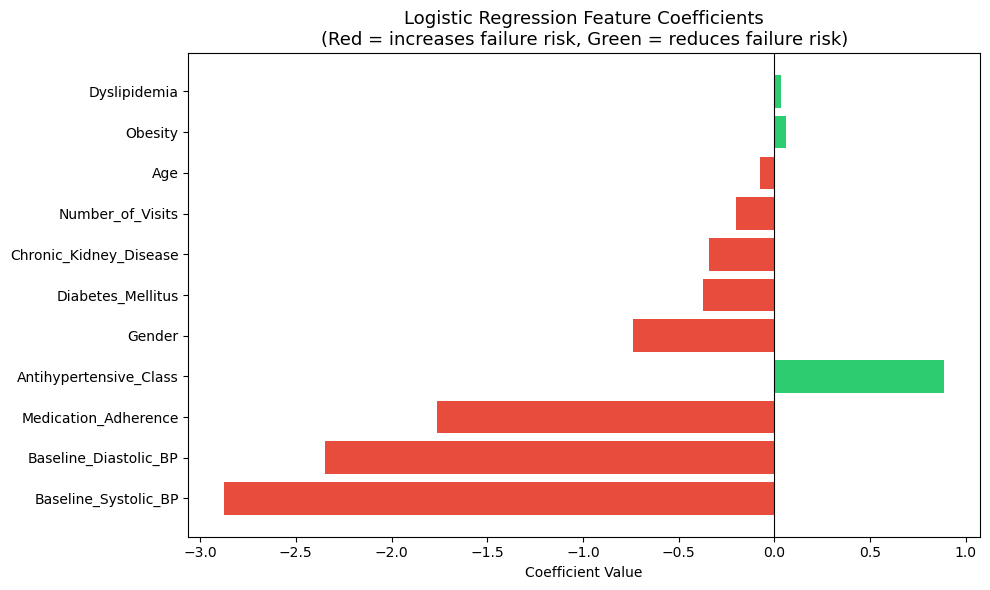

               Feature  Coefficient
  Baseline_Systolic_BP    -2.873707
 Baseline_Diastolic_BP    -2.347182
  Medication_Adherence    -1.760551
Antihypertensive_Class     0.885822
                Gender    -0.737904
     Diabetes_Mellitus    -0.372962
Chronic_Kidney_Disease    -0.341375
      Number_of_Visits    -0.200627
                   Age    -0.075926
               Obesity     0.058647
          Dyslipidemia     0.033116


In [25]:
import numpy as np

# Extract feature coefficients from Logistic Regression
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0]
})

# Sort by absolute value to see strongest predictors
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Feature Coefficients\n(Red = increases failure risk, Green = reduces failure risk)',
          fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('chart7_feature_importance.png', dpi=150)
plt.show()

print(coefficients[['Feature', 'Coefficient']].to_string(index=False))

**Results:**

The two biggest drivers of failure are high starting BP and poor medication adherence, both things the clinic can act on.

## Drug Effectiveness by Comorbidity (Control Rate%)

We break down control rates by drug class *within* each comorbidity group. This answers: for a patient who has diabetes (or CKD, etc.), which drug is associated with the best outcome?

In [27]:
# Define comorbidity segments and drug classes
comorbidities = ['Diabetes_Mellitus', 'Chronic_Kidney_Disease',
                 'Dyslipidemia', 'Obesity']

drug_classes = df['Antihypertensive_Class'].unique()

# Build results table
results = []

for condition in comorbidities:
    # Filter to patients WITH this condition
    segment = df[df[condition] == 'Yes']
    
    for drug in drug_classes:
        drug_segment = segment[segment['Antihypertensive_Class'] == drug]
        n_patients = len(drug_segment)
        
        if n_patients > 0:
            control_rate = (drug_segment['BP_Controlled_After_3_Months'] == 'Yes').mean() * 100
        else:
            control_rate = None
            
        results.append({
            'Comorbidity': condition.replace('_', ' '),
            'Drug_Class': drug,
            'N_Patients': n_patients,
            'Control_Rate_%': round(control_rate, 1) if control_rate is not None else None
        })

results_df = pd.DataFrame(results)

# Print full table
print(results_df.to_string(index=False))

           Comorbidity              Drug_Class  N_Patients  Control_Rate_%
     Diabetes Mellitus           ACE Inhibitor          19             0.0
     Diabetes Mellitus            Beta Blocker          37             8.1
     Diabetes Mellitus Calcium Channel Blocker          26             3.8
     Diabetes Mellitus                     ARB          32             6.2
     Diabetes Mellitus     Combination Therapy          32            25.0
     Diabetes Mellitus       Thiazide Diuretic          36            11.1
Chronic Kidney Disease           ACE Inhibitor          27             0.0
Chronic Kidney Disease            Beta Blocker          35             5.7
Chronic Kidney Disease Calcium Channel Blocker          29             3.4
Chronic Kidney Disease                     ARB          31             3.2
Chronic Kidney Disease     Combination Therapy          26            11.5
Chronic Kidney Disease       Thiazide Diuretic          34            17.6
          Dyslipidemia   

## We visualize 

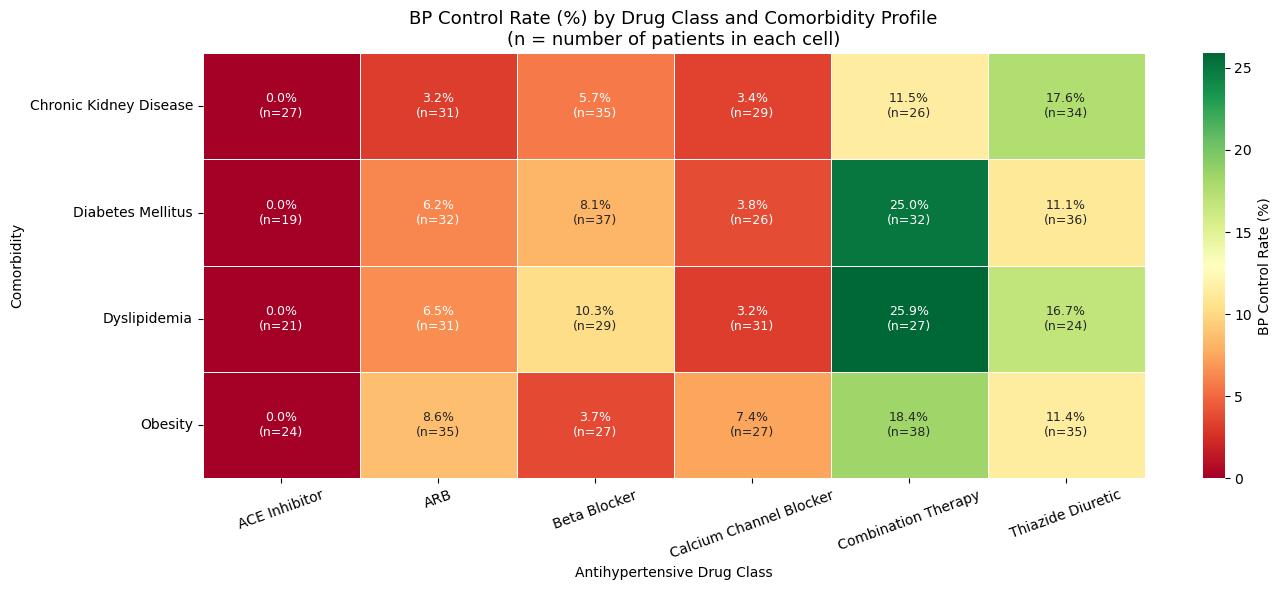

In [28]:
# Pivot table for heatmap
heatmap_data = results_df.pivot(index='Comorbidity', 
                                 columns='Drug_Class', 
                                 values='Control_Rate_%')

# Pivot table for sample sizes (annotations)
size_data = results_df.pivot(index='Comorbidity',
                              columns='Drug_Class',
                              values='N_Patients')

# Create annotation showing both rate and sample size
annotations = heatmap_data.round(1).astype(str) + '%\n(n=' + size_data.astype(str) + ')'

# Plot
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, 
            annot=annotations,
            fmt='',
            cmap='RdYlGn',
            linewidths=0.5,
            cbar_kws={'label': 'BP Control Rate (%)'},
            annot_kws={'size': 9})

plt.title('BP Control Rate (%) by Drug Class and Comorbidity Profile\n(n = number of patients in each cell)',
          fontsize=13)
plt.xlabel('Antihypertensive Drug Class')
plt.ylabel('Comorbidity')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('chart8_comorbidity_heatmap.png', dpi=150)
plt.show()

**Key results:**

Combination therapy consistently performs best. ACE Inhibitors show 0% across all groups, but subgroup sizes are 19–27 patients each. This is not enough to recommend changing prescribing. A multivariate analysis controlling for baseline BP is needed first.

## Average BP Drop by Drug and Comorbidity

Control rate only tells us who crossed 140 mmHg. Average BP drop tells us how much each drug actually reduced blood pressure, regardless of whether patients made it to the target. This gives a fairer picture of drug effectiveness.

In [30]:
# Calculate average BP drop by drug class and comorbidity
bp_results = []

for condition in comorbidities:
    segment = df[df[condition] == 'Yes'].copy()
    segment['BP_Drop'] = segment['Baseline_Systolic_BP'] - segment['Followup_Systolic_BP']
    
    for drug in drug_classes:
        drug_segment = segment[segment['Antihypertensive_Class'] == drug]
        n_patients = len(drug_segment)
        
        if n_patients > 0:
            avg_drop = drug_segment['BP_Drop'].mean()
        else:
            avg_drop = None
            
        bp_results.append({
            'Comorbidity': condition.replace('_', ' '),
            'Drug_Class': drug,
            'N_Patients': n_patients,
            'Avg_BP_Drop_mmHg': round(avg_drop, 1) if avg_drop is not None else None
        })

bp_df = pd.DataFrame(bp_results)
print(bp_df.to_string(index=False))

           Comorbidity              Drug_Class  N_Patients  Avg_BP_Drop_mmHg
     Diabetes Mellitus           ACE Inhibitor          19              15.4
     Diabetes Mellitus            Beta Blocker          37              12.3
     Diabetes Mellitus Calcium Channel Blocker          26              13.2
     Diabetes Mellitus                     ARB          32              11.8
     Diabetes Mellitus     Combination Therapy          32              22.7
     Diabetes Mellitus       Thiazide Diuretic          36              13.0
Chronic Kidney Disease           ACE Inhibitor          27              15.7
Chronic Kidney Disease            Beta Blocker          35              11.6
Chronic Kidney Disease Calcium Channel Blocker          29              11.7
Chronic Kidney Disease                     ARB          31              10.4
Chronic Kidney Disease     Combination Therapy          26              19.6
Chronic Kidney Disease       Thiazide Diuretic          34              12.9

**Key results:**

ACE Inhibitors still drop BP by 15–16 mmHg across all groups, they are working. But patients on them start so far above 140 mmHg that even a 15-point drop does not get them to target. This explains the 0% control rate and confirms the drug selection bias concern from earlier.

## Summary of Findings

1. **Only 9.4% of patients got their BP controlled** — the clinic has a significant outcomes gap
2. **Poor medication adherence is the biggest modifiable risk factor** — patients with poor adherence had a 1.8% control rate vs 15.2% for good adherence
3. **Combination therapy outperformed every single drug** across all comorbidity groups — control rates of 18–26% depending on condition
4. **CKD patients are the hardest to treat** — 7.1% control rate vs 11.9% for patients without it
5. **High starting BP is the strongest predictor of failure** — the model's largest coefficient by a distance
6. **ACE Inhibitors showed 0% control rate** but are still dropping BP by 15–16 mmHg — they appear to be assigned to the sickest patients, not failing outright
7. **The Logistic Regression model at threshold 0.3 catches all 7 controlled patients** in the test set, usable as an early flagging tool

---

## What Could Be Done Next

1. **Run significance tests on drug class differences** — with groups of 19–68 patients, some of these differences could be random chance. A chi-square test would confirm which findings are statistically solid

2. **Control for baseline BP when comparing drugs** — patients on different drugs are not the same. A fairer drug comparison needs to account for how sick each patient was to begin with

3. **Cross-validate the model** — the test set had only 7 controlled patients. K-fold cross-validation would give more reliable performance estimates

4. **Investigate the ACE Inhibitor population specifically** — are these patients sicker at baseline? If yes, the 0% control rate is a selection problem, not a drug problem

5. **Dig into the adherence gap** — 113 out of 350 patients had poor adherence. Understanding *why* (cost, side effects, follow-up frequency) is where the real intervention lives

6. **Track outcomes over a longer window** — 3 months may not be enough for some drug classes or patient profiles. A 6-month follow-up could change the picture